<a href="https://colab.research.google.com/github/Oktavian19/PCVK_Ganjil_2025/blob/main/Week7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [27]:
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [28]:
import numpy as np
import matplotlib.pyplot as plt
import cv2 as cv
import math
from google.colab.patches import cv2_imshow
from PIL import Image as im

## Praktikum Filter

In [29]:
def convolution2d(image, kernel, stride, padding):
  image_height, image_width = image.shape
  kernel_height, kernel_width = kernel.shape

  padded_image = np.pad(
        image,
        pad_width=((padding, padding), (padding, padding)),
        mode='constant',
        constant_values=0
    )

  out_height = (image_height - kernel_height + 2 * padding) // stride + 1
  out_width = (image_width - kernel_width + 2 * padding) // stride + 1

  output = np.zeros((out_height, out_width))

  for y in range(out_height):
        for x in range(out_width):
            region = padded_image[
                y * stride : y * stride + kernel_height,
                x * stride : x * stride + kernel_width
            ]
            output[y, x] = np.sum(region * kernel)

  return output


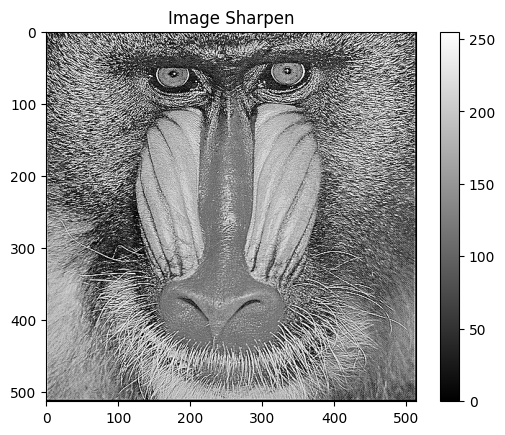

In [30]:
image = cv.imread('/content/drive/MyDrive/asset/mandrill.tiff')
image = cv.cvtColor(image, cv.COLOR_BGR2GRAY)

# image sharpen
kernel_sharpen = np.array([
    [0, -1, 0],
    [-1, 5, -1],
    [0, -1, 0]
])

result = convolution2d(image, kernel_sharpen, 1, 2)
result = np.clip(result, 0, 255).astype(np.uint8)

plt.imshow(result, cmap="gray")   # grayscale color map
plt.colorbar()                    # optional, shows intensity scale
plt.title("Image Sharpen")
plt.show()

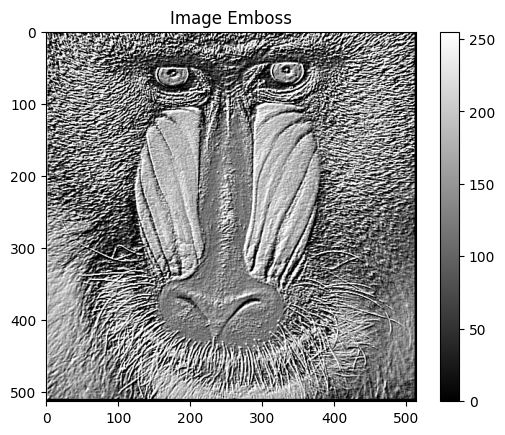

In [31]:
# image emboss
kernel_emboss = np.array([
    [-2, -1, 0],
    [-1, 1, 1],
    [0, 1, 2]
])

result = convolution2d(image, kernel_emboss, 1, 2)
result = np.clip(result, 0, 255).astype(np.uint8)

plt.imshow(result, cmap="gray")   # grayscale color map
plt.colorbar()                    # optional, shows intensity scale
plt.title("Image Emboss")
plt.show()

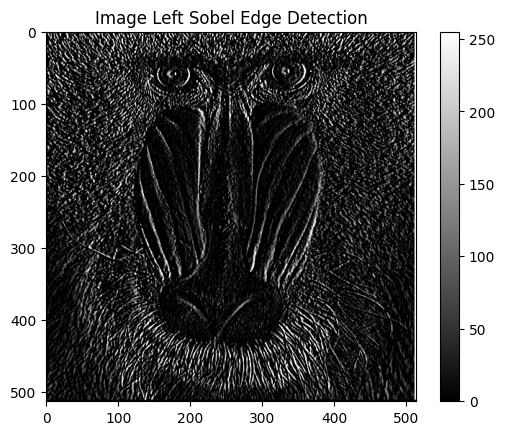

In [32]:
# image lsed
kernel_lsed = np.array([
    [1, 0, -1],
    [2, 0, -2],
    [1, 0, -1]
])

result = convolution2d(image, kernel_lsed, 1, 2)
result = np.clip(result, 0, 255).astype(np.uint8)

plt.imshow(result, cmap="gray")   # grayscale color map
plt.colorbar()                    # optional, shows intensity scale
plt.title("Image Left Sobel Edge Detection")
plt.show()

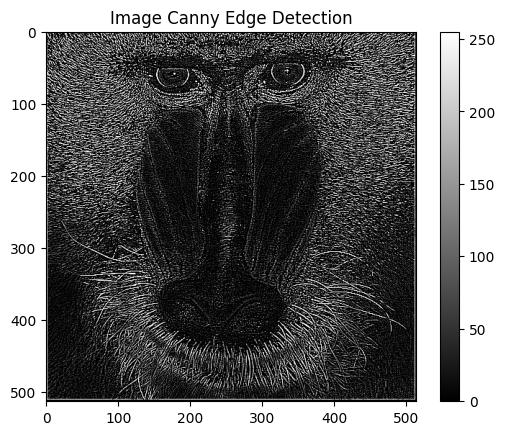

In [33]:
# image cedn
kernel_cedn = np.array([
    [-1, -1, -1],
    [-1, 8, -1],
    [-1, -1, -1]
])

result = convolution2d(image, kernel_cedn, 1, 2)
result = np.clip(result, 0, 255).astype(np.uint8)

plt.imshow(result, cmap="gray")   # grayscale color map
plt.colorbar()                    # optional, shows intensity scale
plt.title("Image Canny Edge Detection")
plt.show()

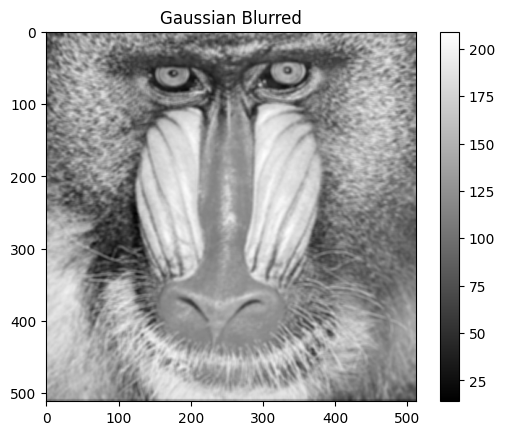

In [34]:
kernel_size = 5
sigma = math.sqrt(kernel_size)

gaussian_kernel = cv.getGaussianKernel(kernel_size, sigma)
gauss_kernel = gaussian_kernel @ gaussian_kernel.T

blurred = cv.filter2D(image, -1, gauss_kernel)

plt.imshow(blurred, cmap="gray")   # grayscale color map
plt.colorbar()                    # optional, shows intensity scale
plt.title("Gaussian Blurred")
plt.show()

## E. Filter Library dan Filter Modern

### Percobaan 1

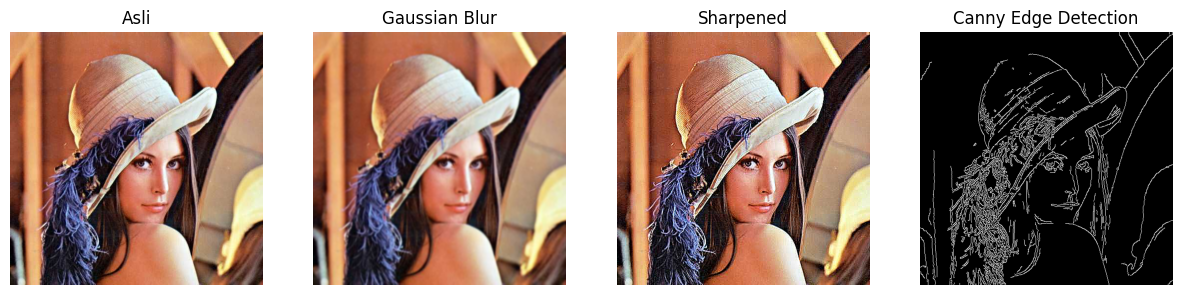

In [35]:
# Fungsi tampil berdampingan
def show_side_by_side(image, titles, figsize=(15, 5)):
  plt.figure(figsize=figsize)
  for i, (img, title) in enumerate(zip(image, titles)):
    if len(img.shape) == 2:
      plt.subplot(1, len(image), i+1)
      plt.imshow(img, cmap="gray")
    else:
      plt.subplot(1, len(image), i+1)
      plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
    plt.title(title)
    plt.axis('off')
  plt.show()

img = cv.imread('/content/drive/MyDrive/asset/lena.jpg')
img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

blur = cv.GaussianBlur(img, (7, 7), 0)
edges = cv.Canny(cv.cvtColor(img, cv.COLOR_BGR2GRAY), 100, 200)
sharpen_kernel = np.array([
    [0, -1, 0],
    [-1, 5, -1],
    [0, -1, 0]
])
sharpened = cv.filter2D(img, -1, sharpen_kernel)
show_side_by_side([img, blur, sharpened, edges],
                  ["Asli", "Gaussian Blur", "Sharpened", "Canny Edge Detection"])


### Percobaan 2

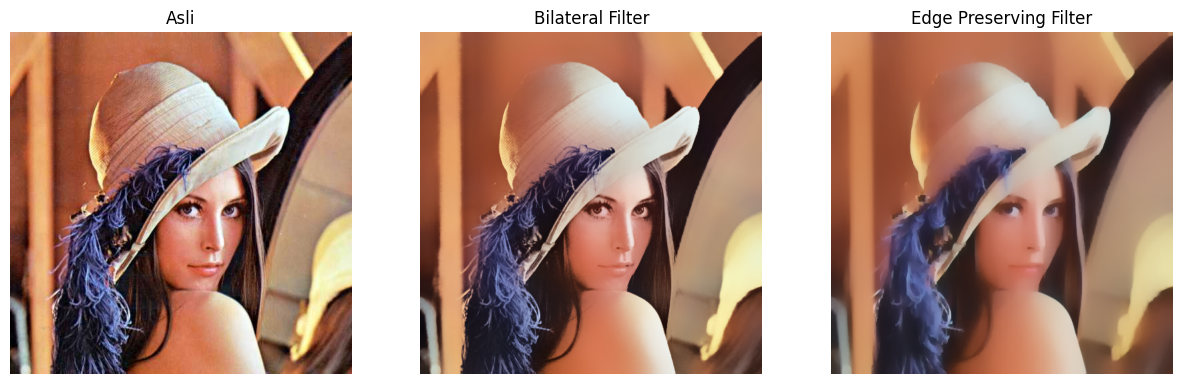

In [36]:
bilateral = cv.bilateralFilter(img, 50, 100, 100)

edge_preserve = cv.edgePreservingFilter(img, flags=1, sigma_s=100, sigma_r=0.9)

show_side_by_side([img, bilateral, edge_preserve],
                  ["Asli", "Bilateral Filter", "Edge Preserving Filter"])

### Percobaan 3

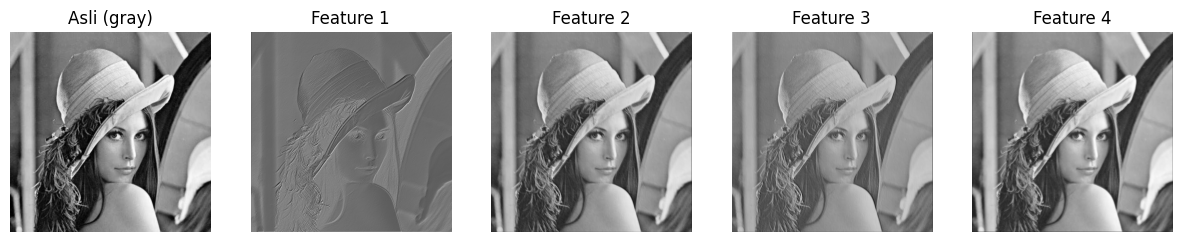

In [42]:
import torch
import torch.nn as nn

class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 4, kernel_size=3, stride=1, padding=1)

    def forward(self, x):
        return self.conv1(x)

model = SimpleCNN()

img_tensor = torch.tensor(img_gray, dtype=torch.float32).unsqueeze(0).unsqueeze(0) / 255.0

with torch.no_grad():
  features = model(img_tensor)

features_maps = [features[0, i].numpy() for i in range(features.shape[1])]

show_side_by_side([img_gray] + features_maps, ["Asli (gray)"] + [f"Feature {i+1}" for i in range(len(features_maps))])

### Percobaan 4

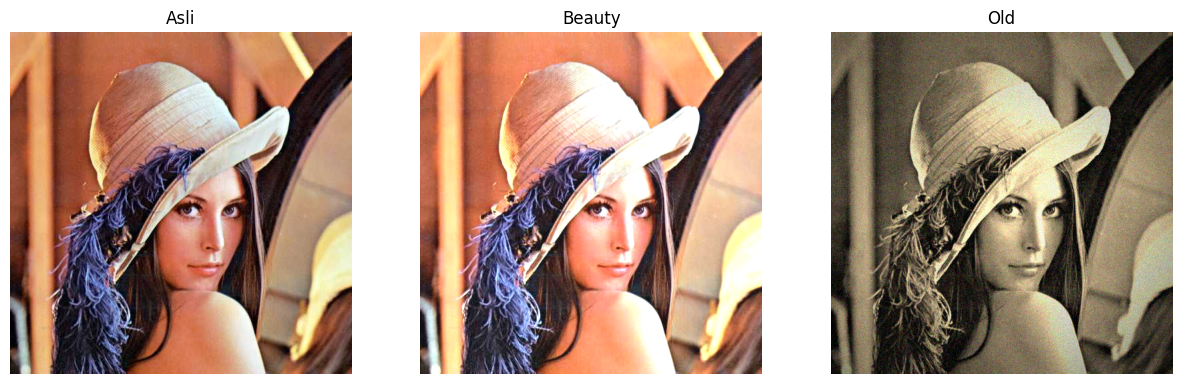

In [44]:
# ==================
# 1. Beauty Filter
# ==================

# Step 1: Smoothing kulit dengan bilaterala filter
smooth = cv.bilateralFilter(img, d=15, sigmaColor=75, sigmaSpace=75)

# Step 2: Unsharp masking (pertajam mata/bibir)
gaussian = cv.GaussianBlur(smooth, (0,0), 3)
sharpened = cv.addWeighted(img, 1.5, gaussian, -0.5, 0)

# Step 3: Brightness & Contrast
alpha = 1.2 # contrast
beta = 15 # brightness
beauty = cv.convertScaleAbs(img, alpha=alpha, beta=beta)

# ======================
# 2. Old/Vintage Filter
# ======================

# Step 1: Sepia tone
sepia_kernel = np.array([[0.272, 0.534, 0.131],
                  [0.349, 0.686, 0.168],
                  [0.393, 0.768, 0.189]])

sepia = cv.transform(img, sepia_kernel)
sepia = np.clip(sepia, 0, 255).astype(np.uint8)

# Step 2: Vignitte
rows, cols = img.shape[:2]
kernel_x = cv.getGaussianKernel(cols, cols*0.6)
kernel_y = cv.getGaussianKernel(rows, cols*0.6)
kernel = kernel_y * kernel_x.T
mask = kernel / kernel.max()
vignitte = np.copy(sepia)
for i in range(3):
  vignitte[:,:,i] = vignitte[:,:,i] * mask

# Step 3: Noise/Grain
noise = np.random.normal(0, 15, vignitte.shape).astype(np.int16)
old_img = np.clip(vignitte + noise, 0, 255).astype(np.uint8)

show_side_by_side([img, beauty, old_img],
                  ["Asli", "Beauty", "Old"])

### Percobaan 5

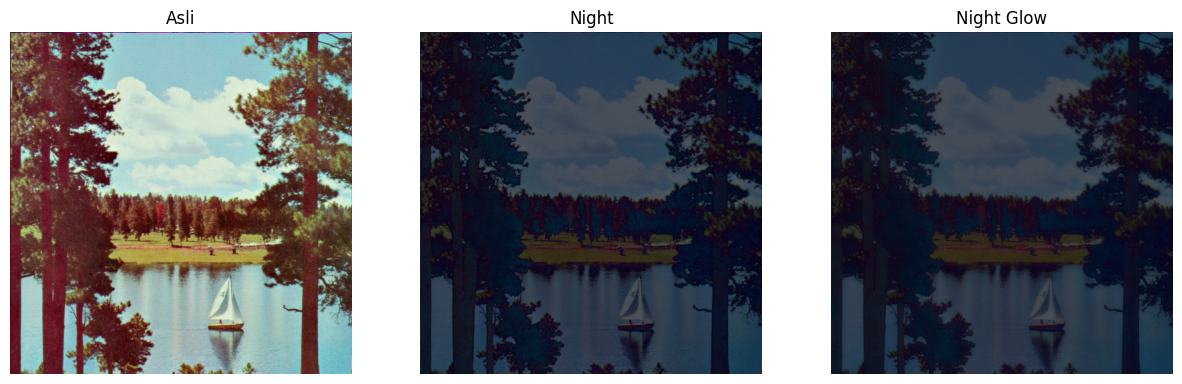

In [47]:
# Night Filter
img = cv.imread('/content/drive/MyDrive/asset/sailboat.tiff')
img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

# Step 1: Gelapkan (contrast turun, brightness negaitf)
night = cv.convertScaleAbs(img, alpha=0.6, beta=-40)

# Step 2: Tambah bias biru
blue_tint = np.full_like(night, (100,0,0))
night = cv.addWeighted(night, 0.8, blue_tint, 0.2, 0)

# Step 3: Efek glow di area terang dengan filter2D (blur kernel)
kernel = np.ones((15,15), np.float32) / 255
glow = cv.filter2D(night, -1, kernel)

# Kombinasikan asli + glow
night_glow = cv.addWeighted(night, 0.7, glow, 0.3, 0)

show_side_by_side([img, night, night_glow],
                  ["Asli", "Night", "Night Glow"])

### Percobaan 7

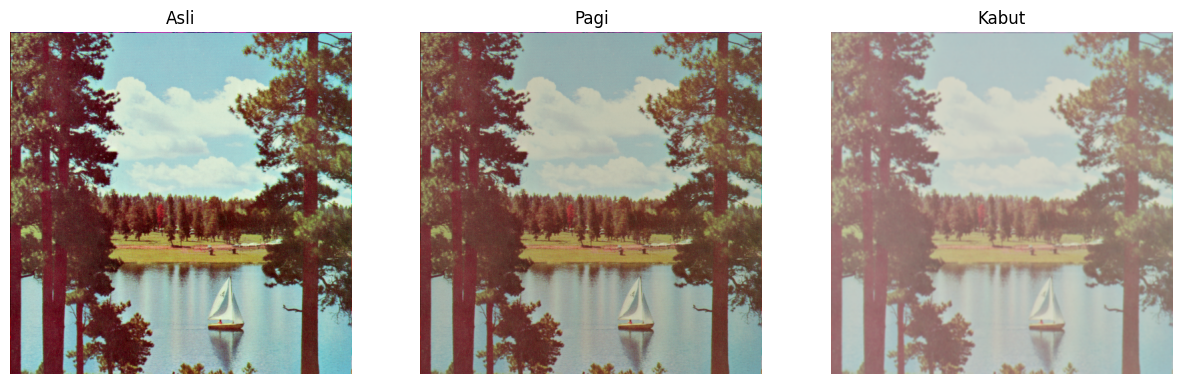

In [50]:
# Filter Suasana pagi dan Kabut

# Step 1: Kurangi kontras & cerahkan
alpha = 0.9
beta = 20
soft = cv.convertScaleAbs(img, alpha=alpha, beta=beta)

# Step 2: Tambahkan warm tone (kemerahan/oranye)
warm_tint = np.full_like(soft, (40, 70, 120))
pagi = cv.addWeighted(soft, 0.8, warm_tint, 0.2, 0)

# Step 3: Tambahkan haze (kabut tipis) dengan filter2D
kernel = cv.getGaussianKernel(3,3)
kernel = kernel @ kernel.T
kabut = cv.filter2D(pagi, -1, kernel)

# tambah layer putih untuk kabut lebih nyata
white_layer = np.full_like(pagi, 255)
kabut = cv.addWeighted(kabut, 0.7, white_layer, 0.3, 0)

show_side_by_side([img, pagi, kabut],
                  ["Asli", "Pagi", "Kabut"])
#